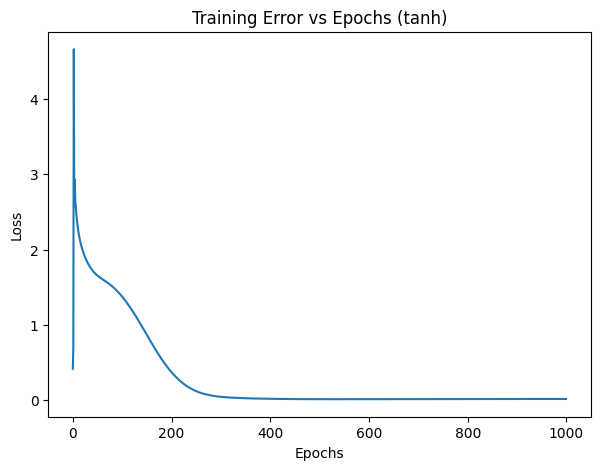

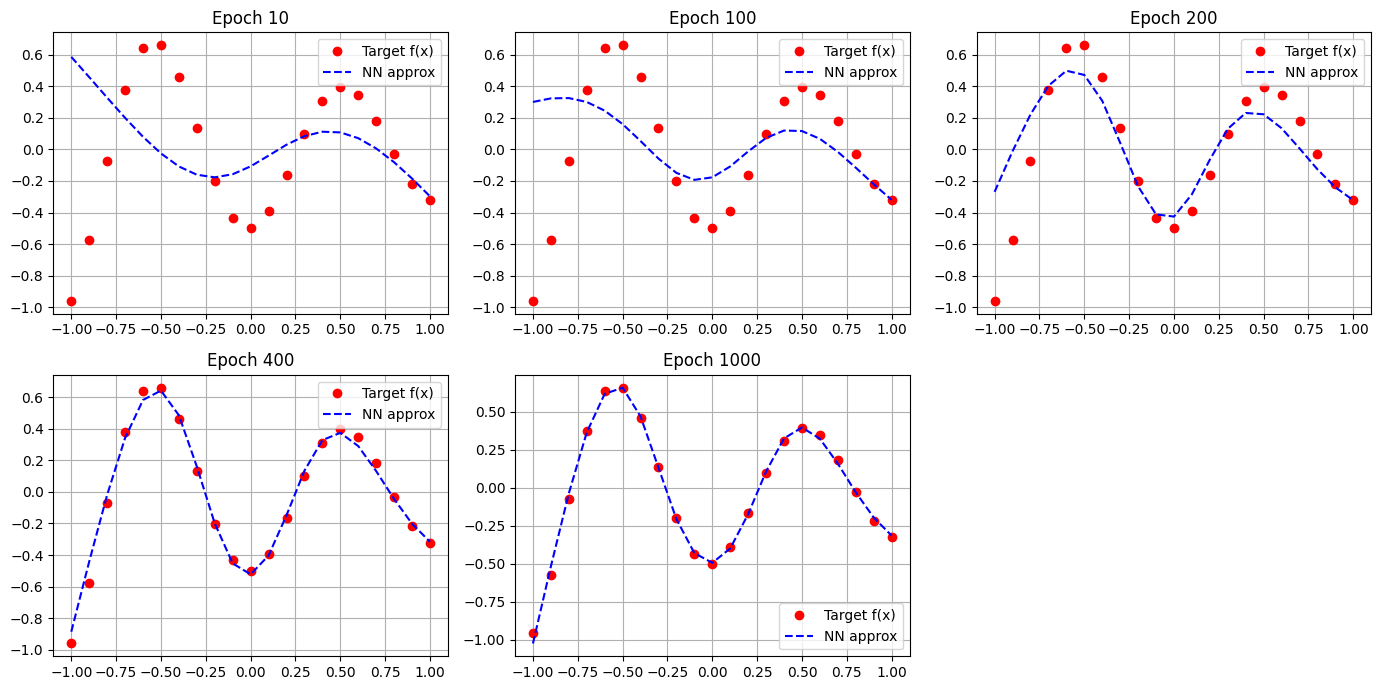

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Activation: tanh
 
def tanh(x): 
    return np.tanh(x)

def tanh_deriv(x): 
    return 1 - np.tanh(x)**2

 
# Data
 
X = np.arange(-1, 1.1, 0.1).reshape(-1,1)
Y = np.array([
    -0.96, -0.577, -0.073, 0.377, 0.641, 0.66,
     0.461, 0.134, -0.201, -0.434, -0.5, -0.393,
    -0.165, 0.099, 0.307, 0.396, 0.345, 0.182,
    -0.031, -0.219, -0.321
]).reshape(-1,1)

 
# Network dimensions
 
n_in, n_hidden, n_out = 1, 30, 1

# Xavier initialization
np.random.seed(42)
W1 = np.random.randn(n_hidden, n_in) * 1
b1 = np.zeros((n_hidden,1))
W2 = np.random.randn(n_out, n_hidden) * 1
b2 = np.zeros((n_out,1))

# Hyperparameters
lr = 0.05
epochs = 1000
losses = []
snapshots = {}

 
# Training loop
 
for epoch in range(epochs):
    total_loss = 0
    for x, y in zip(X, Y):
        x = x.reshape(-1,1)
        y = y.reshape(-1,1)

        # Forward
        z1 = W1 @ x + b1
        a1 = tanh(z1)
        z2 = W2 @ a1 + b2
        y_hat = z2

        # Loss
        total_loss += 0.5 * np.sum((y_hat - y)**2)

        # Backprop
        delta2 = y_hat - y
        dW2 = delta2 @ a1.T
        db2 = delta2

        da1 = W2.T @ delta2
        delta1 = da1 * tanh_deriv(z1)
        dW1 = delta1 @ x.T
        db1 = delta1

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    losses.append(total_loss)
    if (epoch+1) in [10, 100, 200, 400, 1000]:
        snapshots[epoch+1] = (W1.copy(), b1.copy(), W2.copy(), b2.copy())

 
# Plot training loss
 
plt.figure(figsize=(7,5))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Error vs Epochs (tanh)")
# plt.grid(True)
plt.show()

 
# Subplots for approximations
plt.figure(figsize=(14,7))
plot_index = 1
for e,(W1s,b1s,W2s,b2s) in snapshots.items():
    preds = []
    for x in X:
        x = x.reshape(-1,1)
        a1 = tanh(W1s @ x + b1s)
        y_hat = W2s @ a1 + b2s
        preds.append(y_hat.item())
    preds = np.array(preds)

    plt.subplot(2,3,plot_index)
    plt.plot(X, Y, "ro", label="Target f(x)")
    plt.plot(X, preds, "b--", label="NN approx")
    plt.title(f"Epoch {e}")
    plt.legend()
    plt.grid(True)
    plot_index += 1

plt.tight_layout()
plt.show()


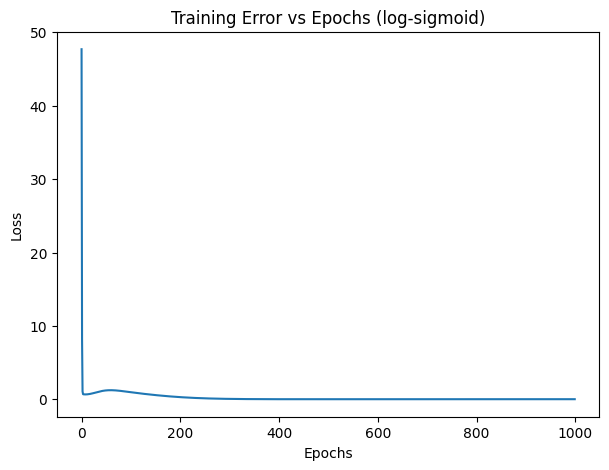

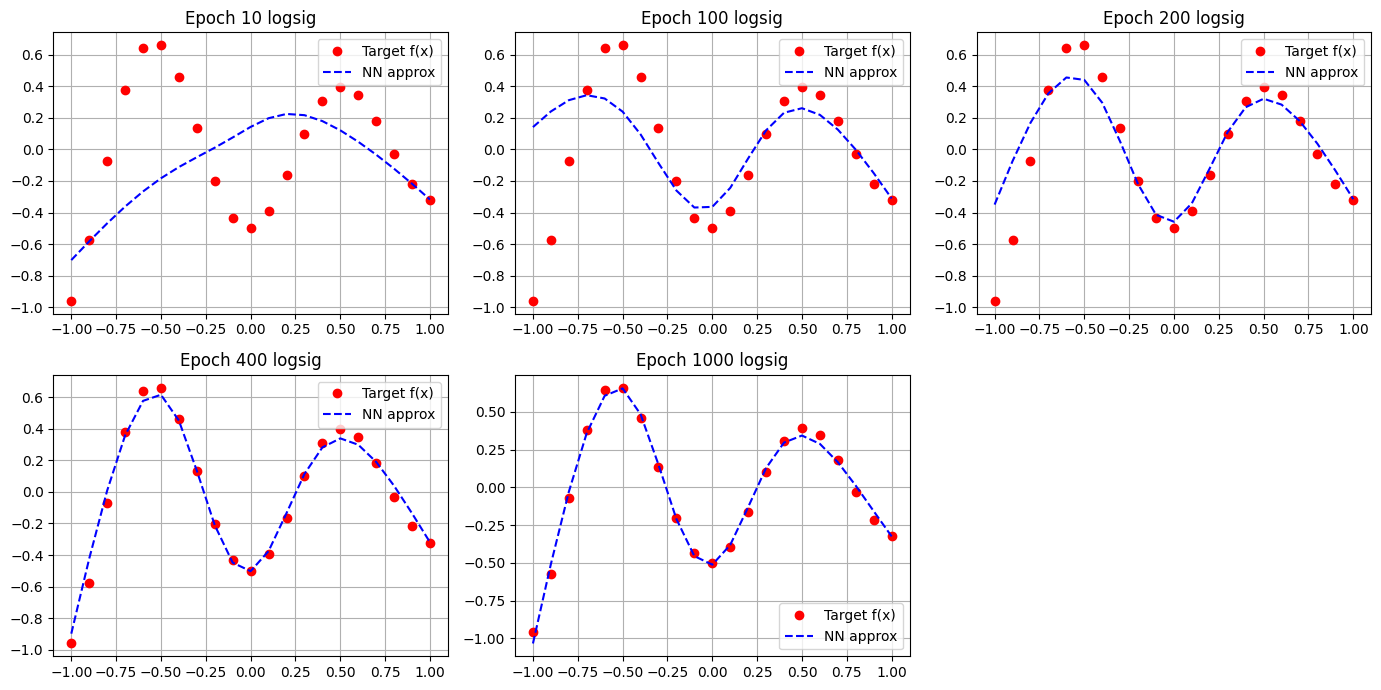

In [2]:
import numpy as np
import matplotlib.pyplot as plt

 
# Activation: logistic sigmoid
 
def logsig(x):
    return 1.0 / (1.0 + np.exp(-x))

def logsig_deriv(x):
    a = logsig(x)
    return a * (1.0 - a)

 
# Data
 
X = np.arange(-1, 1.1, 0.1).reshape(-1,1)
Y = np.array([
    -0.96, -0.577, -0.073, 0.377, 0.641, 0.66,
     0.461, 0.134, -0.201, -0.434, -0.5, -0.393,
    -0.165, 0.099, 0.307, 0.396, 0.345, 0.182,
    -0.031, -0.219, -0.321
]).reshape(-1,1)

 
# Network dimensions
 
n_in, n_hidden, n_out = 1, 15, 1

# Xavier initialization
np.random.seed(42)
W1 = np.random.randn(n_hidden, n_in) * 3
b1 = np.zeros((n_hidden,1))
W2 = np.random.randn(n_out, n_hidden) * 3
b2 = np.zeros((n_out,1))

# Hyperparameters
lr = 0.1
epochs = 1000
losses = []
snapshots = {}

 
# Training loop
 
for epoch in range(epochs):
    total_loss = 0.0
    for x, y in zip(X, Y):
        x = x.reshape(-1,1)
        y = y.reshape(-1,1)

        # Forward
        z1 = W1 @ x + b1
        a1 = logsig(z1)                 # <-- sigmoid
        z2 = W2 @ a1 + b2
        y_hat = z2

        # Loss (MSE)
        total_loss += 0.5 * np.sum((y_hat - y)**2)

        # Backprop
        delta2 = y_hat - y
        dW2 = delta2 @ a1.T
        db2 = delta2

        da1 = W2.T @ delta2
        delta1 = da1 * logsig_deriv(z1) # <-- sigmoid derivative
        dW1 = delta1 @ x.T
        db1 = delta1

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    losses.append(total_loss)
    if (epoch+1) in [10, 100, 200, 400, 1000]:
        snapshots[epoch+1] = (W1.copy(), b1.copy(), W2.copy(), b2.copy())

 
# Plot training loss
 
plt.figure(figsize=(7,5))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Error vs Epochs (log-sigmoid)")
plt.show()

 
# Subplots for approximations
 
plt.figure(figsize=(14,7))
plot_index = 1
for e,(W1s,b1s,W2s,b2s) in snapshots.items():
    preds = []
    for x in X:
        x = x.reshape(-1,1)
        a1 = logsig(W1s @ x + b1s)      # <-- sigmoid
        y_hat = W2s @ a1 + b2s
        preds.append(y_hat.item())
    preds = np.array(preds)

    plt.subplot(2,3,plot_index)
    plt.plot(X, Y, "ro", label="Target f(x)")
    plt.plot(X, preds, "b--", label="NN approx")
    plt.title(f"Epoch {e} logsig")
    plt.legend()
    plt.grid(True)
    plot_index += 1

plt.tight_layout()
plt.show()


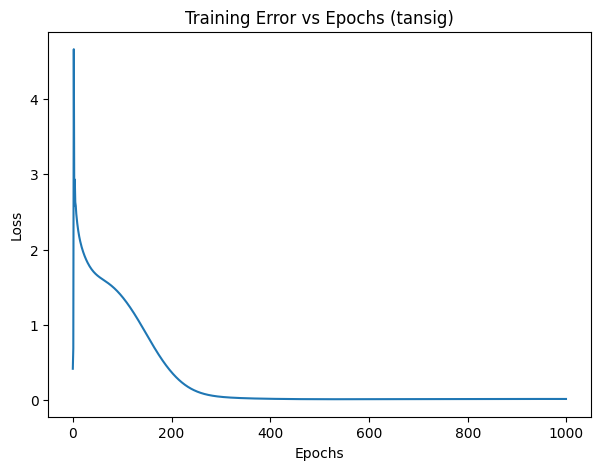

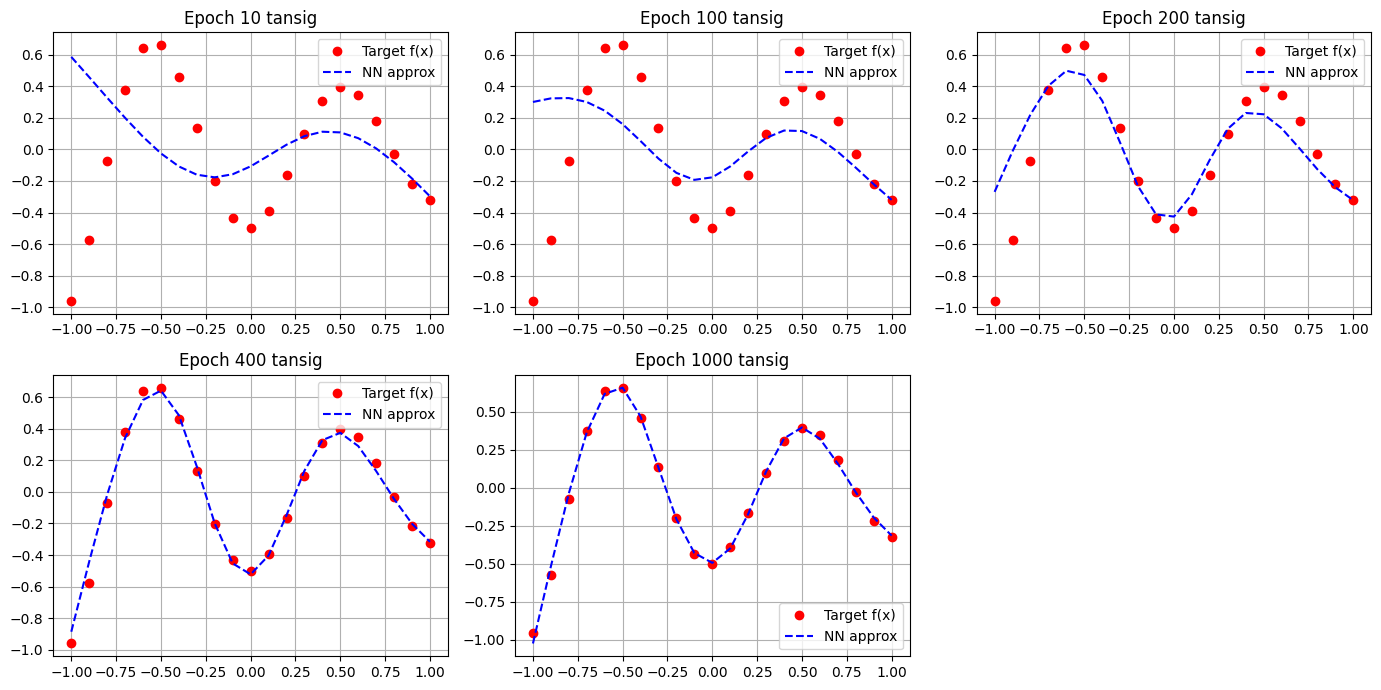

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

 
# Activation: tansig (tanh)
 
def tansig(x):
    return np.tanh(x)

def tansig_deriv(x):
    return 1.0 - np.tanh(x)**2

 
# Data
 
X = np.arange(-1, 1.1, 0.1).reshape(-1,1)
Y = np.array([
    -0.96, -0.577, -0.073, 0.377, 0.641, 0.66,
     0.461, 0.134, -0.201, -0.434, -0.5, -0.393,
    -0.165, 0.099, 0.307, 0.396, 0.345, 0.182,
    -0.031, -0.219, -0.321
]).reshape(-1,1)

 
# Network dimensions
 
n_in, n_hidden, n_out = 1, 30, 1

# Initialization 
np.random.seed(42)
W1 = np.random.randn(n_hidden, n_in) 
b1 = np.zeros((n_hidden,1))
W2 = np.random.randn(n_out, n_hidden) 
b2 = np.zeros((n_out,1))

# Hyperparameters
lr = 0.05
epochs = 1000
losses = []
snapshots = {}

 
# Training loop
 
for epoch in range(epochs):
    total_loss = 0.0
    for x, y in zip(X, Y):
        x = x.reshape(-1,1)
        y = y.reshape(-1,1)

        # Forward
        z1 = W1 @ x + b1
        a1 = tansig(z1)
        z2 = W2 @ a1 + b2
        y_hat = z2

        # Loss (MSE)
        total_loss += 0.5 * np.sum((y_hat - y)**2)

        # Backprop
        delta2 = y_hat - y
        dW2 = delta2 @ a1.T
        db2 = delta2

        da1 = W2.T @ delta2
        delta1 = da1 * tansig_deriv(z1)
        dW1 = delta1 @ x.T
        db1 = delta1

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    losses.append(total_loss)
    if (epoch+1) in [10, 100, 200, 400, 1000]:
        snapshots[epoch+1] = (W1.copy(), b1.copy(), W2.copy(), b2.copy())

 
# Plot training loss
 
plt.figure(figsize=(7,5))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Error vs Epochs (tansig)")
plt.show()

 
# Subplots for approximations
 
plt.figure(figsize=(14,7))
plot_index = 1
for e,(W1s,b1s,W2s,b2s) in snapshots.items():
    preds = []
    for x in X:
        x = x.reshape(-1,1)
        a1 = tansig(W1s @ x + b1s)
        y_hat = W2s @ a1 + b2s
        preds.append(y_hat.item())
    preds = np.array(preds)

    plt.subplot(2,3,plot_index)
    plt.plot(X, Y, "ro", label="Target f(x)")
    plt.plot(X, preds, "b--", label="NN approx")
    plt.title(f"Epoch {e} tansig")
    plt.legend()
    plt.grid(True)
    plot_index += 1

plt.tight_layout()
plt.show()


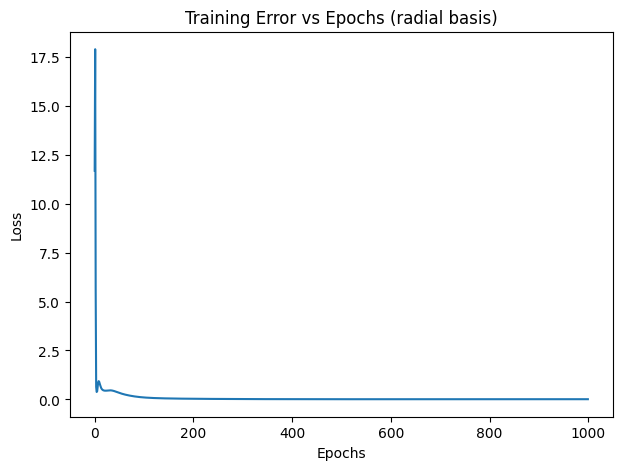

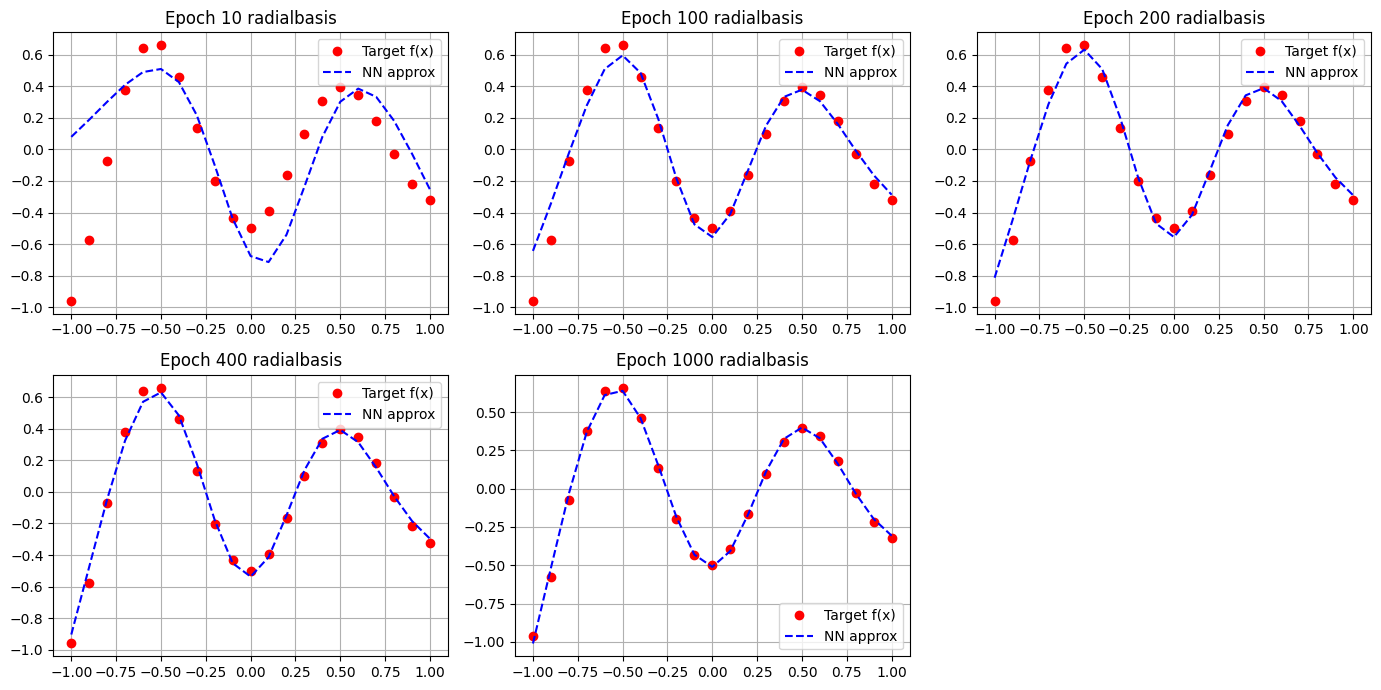

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

 
# Activation: radial basis φ(x)=exp(-x^2)
 
def radialbasis(x):
    return np.exp(-x**2)

def radialbasis_deriv(x):
    return -2.0 * x * np.exp(-x**2)

 
# Data
 
X = np.arange(-1, 1.1, 0.1).reshape(-1,1)
Y = np.array([
    -0.96, -0.577, -0.073, 0.377, 0.641, 0.66,
     0.461, 0.134, -0.201, -0.434, -0.5, -0.393,
    -0.165, 0.099, 0.307, 0.396, 0.345, 0.182,
    -0.031, -0.219, -0.321
]).reshape(-1,1)

 
# Network dimensions
 
n_in, n_hidden, n_out = 1, 15, 1

# Initialization 
np.random.seed(42)
W1 = np.random.randn(n_hidden, n_in) * 1.5
b1 = np.zeros((n_hidden,1))
W2 = np.random.randn(n_out, n_hidden) * 1.5
b2 = np.zeros((n_out,1))

# Hyperparameters
lr = 0.1
epochs = 1000
losses = []
snapshots = {}

 
# Training loop
 
for epoch in range(epochs):
    total_loss = 0.0
    for x, y in zip(X, Y):
        x = x.reshape(-1,1)
        y = y.reshape(-1,1)

        # Forward
        z1 = W1 @ x + b1
        a1 = radialbasis(z1)
        z2 = W2 @ a1 + b2
        y_hat = z2

        # Loss (MSE)
        total_loss += 0.5 * np.sum((y_hat - y)**2)

        # Backprop
        delta2 = y_hat - y
        dW2 = delta2 @ a1.T
        db2 = delta2

        da1 = W2.T @ delta2
        delta1 = da1 * radialbasis_deriv(z1)
        dW1 = delta1 @ x.T
        db1 = delta1

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    losses.append(total_loss)
    if (epoch+1) in [10, 100, 200, 400, 1000]:
        snapshots[epoch+1] = (W1.copy(), b1.copy(), W2.copy(), b2.copy())

 
# Plot training loss
 
plt.figure(figsize=(7,5))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Error vs Epochs (radial basis)")
plt.show()

 
# Subplots for approximations
 
plt.figure(figsize=(14,7))
plot_index = 1
for e,(W1s,b1s,W2s,b2s) in snapshots.items():
    preds = []
    for x in X:
        x = x.reshape(-1,1)
        a1 = radialbasis(W1s @ x + b1s)
        y_hat = W2s @ a1 + b2s
        preds.append(y_hat.item())
    preds = np.array(preds)

    plt.subplot(2,3,plot_index)
    plt.plot(X, Y, "ro", label="Target f(x)")
    plt.plot(X, preds, "b--", label="NN approx")
    plt.title(f"Epoch {e} radialbasis")
    plt.legend()
    plt.grid(True)
    plot_index += 1

plt.tight_layout()
plt.show()


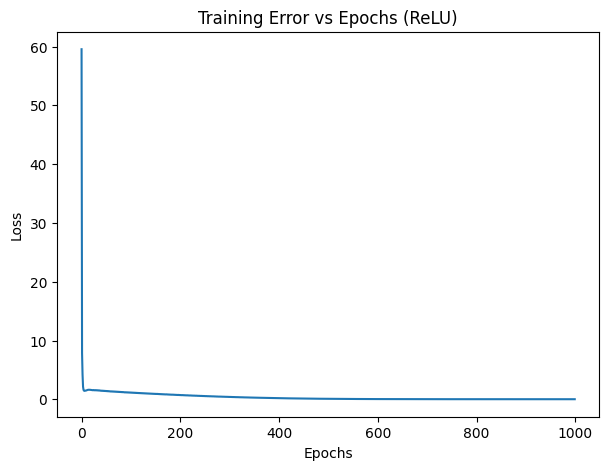

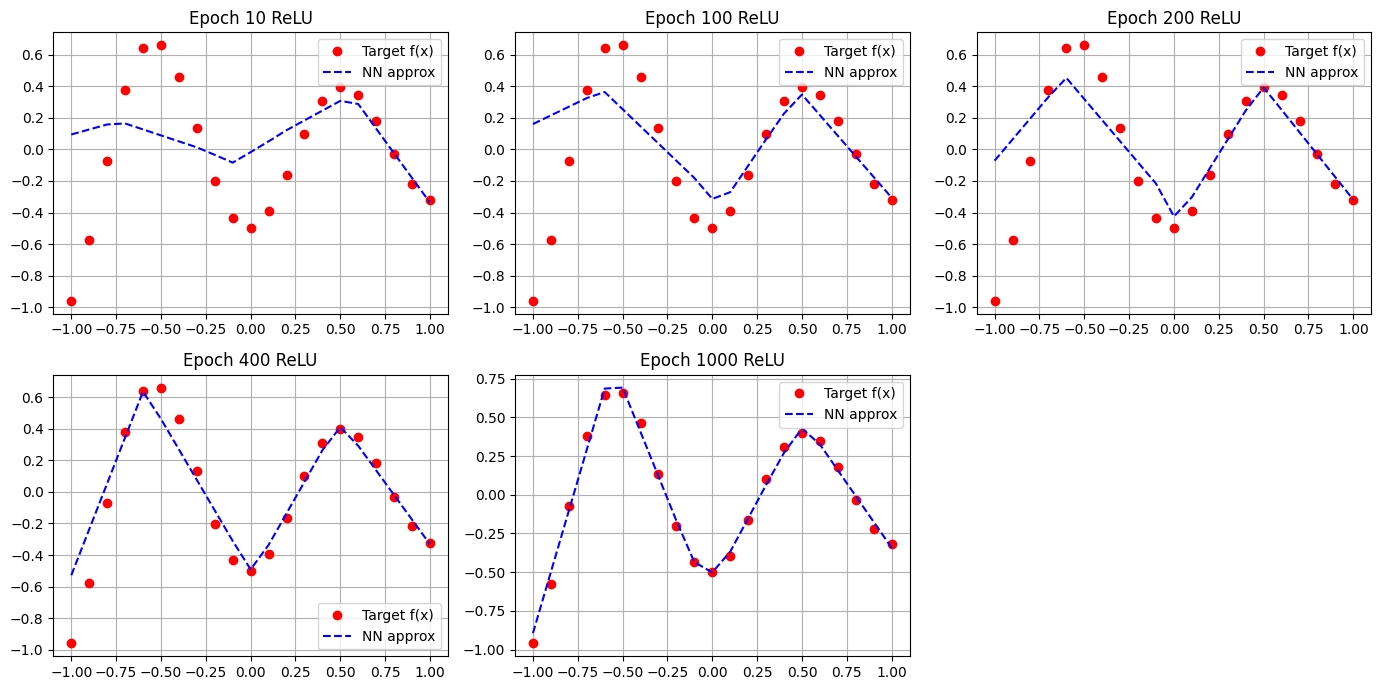

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

 
# Activation: ReLU
 
def relu(x):
    return np.maximum(0.0, x)

def relu_deriv(x):
    return (x > 0.0).astype(float)

 
# Data
 
X = np.arange(-1, 1.1, 0.1).reshape(-1,1)
Y = np.array([
    -0.96, -0.577, -0.073, 0.377, 0.641, 0.66,
     0.461, 0.134, -0.201, -0.434, -0.5, -0.393,
    -0.165, 0.099, 0.307, 0.396, 0.345, 0.182,
    -0.031, -0.219, -0.321
]).reshape(-1,1)

 
# Network dimensions
 
n_in, n_hidden, n_out = 1, 30, 1

# Initialization 
np.random.seed(42)
W1 = np.random.randn(n_hidden, n_in) * np.sqrt(2/n_in)
b1 = np.zeros((n_hidden,1))
W2 = np.random.randn(n_out, n_hidden) * np.sqrt(2/n_in)
b2 = np.zeros((n_out,1))

# Hyperparameters
lr = 0.01
epochs = 1000
losses = []
snapshots = {}

 
# Training loop
 
for epoch in range(epochs):
    total_loss = 0.0
    for x, y in zip(X, Y):
        x = x.reshape(-1,1)
        y = y.reshape(-1,1)

        # Forward
        z1 = W1 @ x + b1
        a1 = relu(z1)
        z2 = W2 @ a1 + b2
        y_hat = z2

        # Loss (MSE)
        total_loss += 0.5 * np.sum((y_hat - y)**2)

        # Backprop
        delta2 = y_hat - y
        dW2 = delta2 @ a1.T
        db2 = delta2

        da1 = W2.T @ delta2
        delta1 = da1 * relu_deriv(z1)
        dW1 = delta1 @ x.T
        db1 = delta1

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    losses.append(total_loss)
    if (epoch+1) in [10, 100, 200, 400, 1000]:
        snapshots[epoch+1] = (W1.copy(), b1.copy(), W2.copy(), b2.copy())

 
# Plot training loss
 
plt.figure(figsize=(7,5))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Error vs Epochs (ReLU)")
plt.show()

 
# Subplots for approximations
 
plt.figure(figsize=(14,7))
plot_index = 1
for e,(W1s,b1s,W2s,b2s) in snapshots.items():
    preds = []
    for x in X:
        x = x.reshape(-1,1)
        a1 = relu(W1s @ x + b1s)
        y_hat = W2s @ a1 + b2s
        preds.append(y_hat.item())
    preds = np.array(preds)

    plt.subplot(2,3,plot_index)
    plt.plot(X, Y, "ro", label="Target f(x)")
    plt.plot(X, preds, "b--", label="NN approx")
    plt.title(f"Epoch {e} ReLU")
    plt.legend()
    plt.grid(True)
    plot_index += 1

plt.tight_layout()
plt.show()
